<a href="https://colab.research.google.com/github/jexcel00/NLP-lab/blob/main/lab3Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


Part A: Loading and Exploring the 20 Newsgroups Dataset

In [7]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/" + splits["train"], lines=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [8]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


In [9]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["rec.motorcycles", "rec.sport.baseball", "rec.sport.hockey"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey']
Filtered dataset size: 1795

Distribution:
label_text
rec.sport.hockey      600
rec.motorcycles       598
rec.sport.baseball    597
Name: count, dtype: int64


Written Question A.1 (Personal Interpretation)
Why did you choose these 3 specific categories? Explain your reasoning (at least 3 sentences).

I choose these 3 specific categories because the 3 are about sport, so they are related. That's interest me because i am a sports fan


Part B: Text Preprocessing Function

In [10]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower() # YOUR CODE HERE
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) # YOUR CODE HERE
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text) # YOUR CODE HERE
    # Remove numbers
    text = re.sub(r'\d+', '', text) # YOUR CODE HERE
    # Remove punctuation
    text =text.translate(str.maketrans('', '', string.punctuation)) # YOUR CODE HERE
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip() # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


Exercise B.1: Improve the Preprocessing Function

In [11]:
# TODO: Complete this improved preprocessing function

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
     # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: Tokenize
    tokens = tokens = text.split()

    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]

    # Step 6: Join back to string
    cleaned_text = " ".join(tokens)

    return cleaned_text  # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [12]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
line ducati gts model clock run well paint bronzebrownorange faded leak bit oil pop hard accel shop fix trans oil leak sold bike owner want thinking like opinion please email thanks would nice stable mate beemer ill get jap bike call axis motor tuba irwin honk therefore computracrichardsontx dod



Part C: Text Visualization
C.1 Bar Chart: Top Words per Category

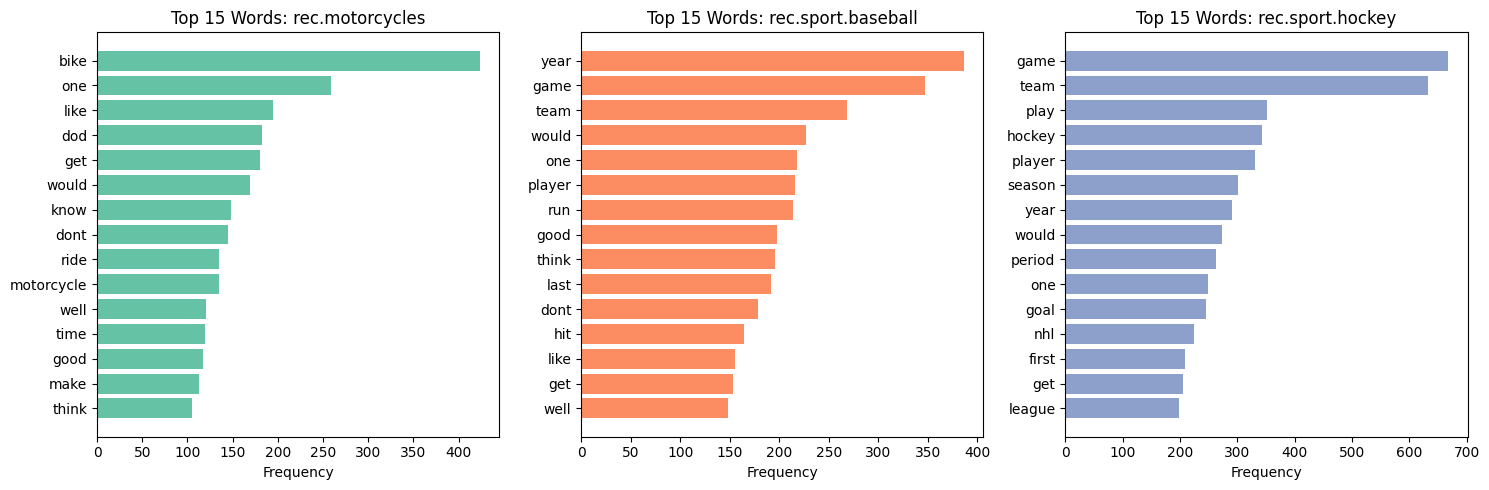

In [13]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Written Question C.1 (Personal Interpretation)

What words are UNIQUE to each category? (List at least 2 per category)

What words are SHARED across categories?

Why do you think they appear in multiple categories?

Based ONLY on the top words, could you guess the topic of each category? Explain.

Category 1 motocycle:

Unique words: bike & ride

Category 2 baseball:

Unique words: well & like

Category 3 hockey:

Unique words: goal & Nhl

Shared words and explanation: one (maybe is about a ranking)

Topic guessing analysis: No i wouldn't because the word is no descriptive enough to be able to identify a specific sport

C.2 Word Clouds

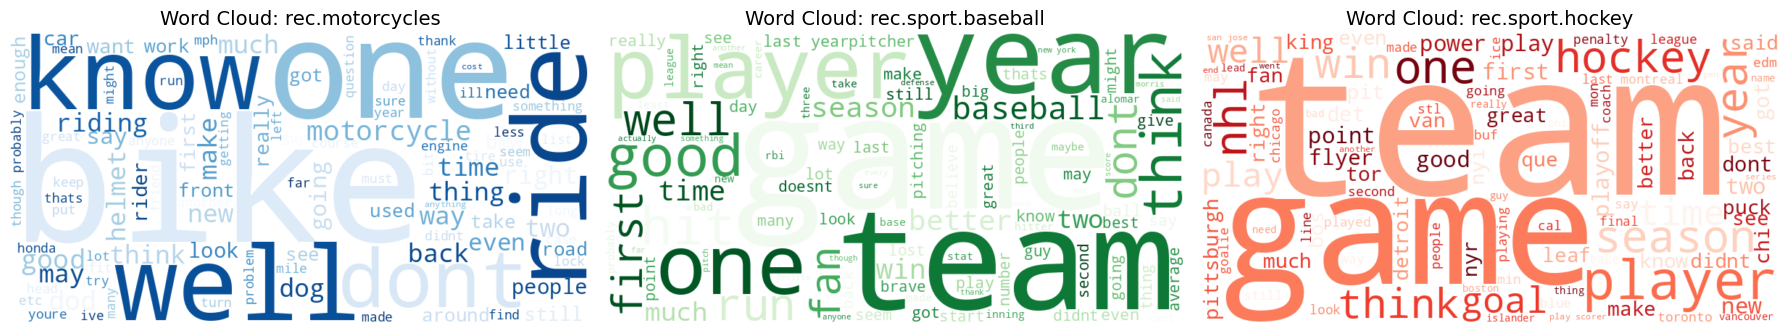

In [14]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Exercise C.2: Custom Shaped Word Cloud
Create a word cloud using a custom mask image.

Instructions:

Find or create a simple black & white silhouette image (PNG format)
Save it in your working directory
Use it as a mask for your word cloud
Tip: You can use any simple shape (circle, star, heart) or find free silhouettes online.

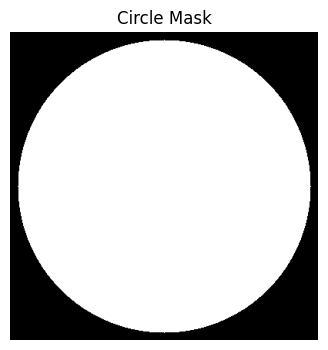

In [15]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

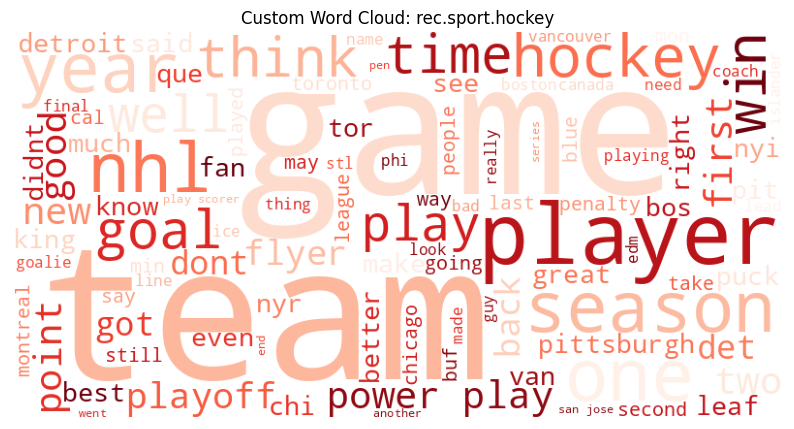

In [16]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "rec.sport.hockey"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
#wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)
wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
        ).generate(text_combined)

wordcloud_masked = wordcloud  # YOUR CODE HERE

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, cmap='gray')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

Part D: Bag of Words (BoW) Representation

In [17]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


Exercise D.1: Create BoW for Your Dataset

In [18]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
     max_features=1000, min_df=5, max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1795, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['aaa' 'abc' 'ability' 'able' 'according' 'acquired' 'across' 'actually'
 'adam' 'add' 'address' 'adirondack' 'advance' 'advantage' 'advice' 'age'
 'ago' 'agree' 'ahead' 'ahl']


Exercise D.2: Document Similarity with BoW

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)  # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1795, 1795)


In [20]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE
similarity_matrix = cosine_similarity(bow_matrix_full)

similarity_matrix_no_diag = similarity_matrix.copy()
np.fill_diagonal(similarity_matrix_no_diag, -1)

# Find indices of most similar pair
most_similar_idx = np.unravel_index(
    np.argmax(similarity_matrix_no_diag),
    similarity_matrix_no_diag.shape
)
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(595), np.int64(1048))
Similarity score: 1.0000000000000002

Document 1 category: rec.sport.hockey
Document 2 category: rec.sport.hockey


In [21]:
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['text_clean']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['text_clean']}")


Document 1 category: meaningless compare one player plusminus statistic another player context role playing time player involved compare jagrs franciss plusminus ridiculous absurd gerald thank putting perspective
Document 2 category: meaningless compare one player plusminus statistic another player context role playing time player involved compare jagrs franciss plusminus ridiculous absurd


In [22]:
# Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# Exclude self-similarity by setting diagonal to -1
np.fill_diagonal(similarity_matrix, -1)

# Find indices of most similar pair
most_similar_idx_flat = np.argmax(similarity_matrix)
most_similar_idx = np.unravel_index(most_similar_idx_flat, similarity_matrix.shape)
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(595), np.int64(1048))
Similarity score: 1.0000000000000002

Document 1 category: rec.sport.hockey
Document 2 category: rec.sport.hockey


Written Question D.1 (Personal Interpretation)
Look at the 2 most similar documents you found:

Are they from the same category or different categories?
Read the original texts (first 200 characters). What makes them similar?
Is the BoW similarity measure meaningful here? Why or why not?

In [23]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
: It is meaningless to compare one player's plus/minus statistic with
: another players' out of the context of the role and the playing time
: of the players involved.    

: To compare Jagr's and Francis's plus/minus is ridiculous and absurd...

: Gerald

Thank you for putting this in perspective!



Document 2 (first 300 chars):
It is meaningless to compare one player's plus/minus statistic with
another players' out of the context of the role and the playing time
of the players involved.    

To compare Jagr's and Francis's plus/minus is ridiculous and absurd...



Part E: TF-IDF Representation

In [24]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [25]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


Exercise E.1: TF-IDF Analysis

In [27]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    # YOUR PARAMETERS HERE
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1795, 16116)


In [28]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    # 2. Get their TF-IDF vectors
    # 3. Compute mean TF-IDF for each word across these documents
    # 4. Return top n words
    pass

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'rec.motorcycles':
None

Top TF-IDF words for 'rec.sport.baseball':
None

Top TF-IDF words for 'rec.sport.hockey':
None


Written Question E.1 (Personal Interpretation)
Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

What words appear in TF-IDF top 10 but NOT in the word count top 15?
What words appear in word count top 15 but NOT in TF-IDF top 10?
Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.
YOUR ANSWER:

[Write your comparative analysis here]

Words in TF-IDF but not counts: ...

Words in counts but not TF-IDF: ...

Which method is better and why: ...


Part F: N-grams and Next Word Prediction

In [29]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [30]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


Exercise F.1: Analyze Bigrams in Your Dataset

In [31]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # YOUR CODE HERE
    top_bigrams = []  # Get top 15 bigrams

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'rec.motorcycles':

Top bigrams for 'rec.sport.baseball':

Top bigrams for 'rec.sport.hockey':


Exercise F.2: Simple Next Word Predictor
Build a simple next-word predictor using bigram probabilities.

In [32]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)
        pass

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        # 3. Return top_n predictions sorted by probability
        return []

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())